In [1]:
import urllib.request
import matplotlib.pyplot as plt
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x2bb18847aa0>)

In [2]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [3]:
#are there any missing data?
#are there NaNs in the data?

#this will get both missing data and NaNs in the data since pandas should recognize "NaN", "NA", "null", or "N/A" as missing
missing_per_column = df_stars.isna().sum()
print(missing_per_column)
print(df_stars.info())  

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    object 
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 13.3+ KB
None


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


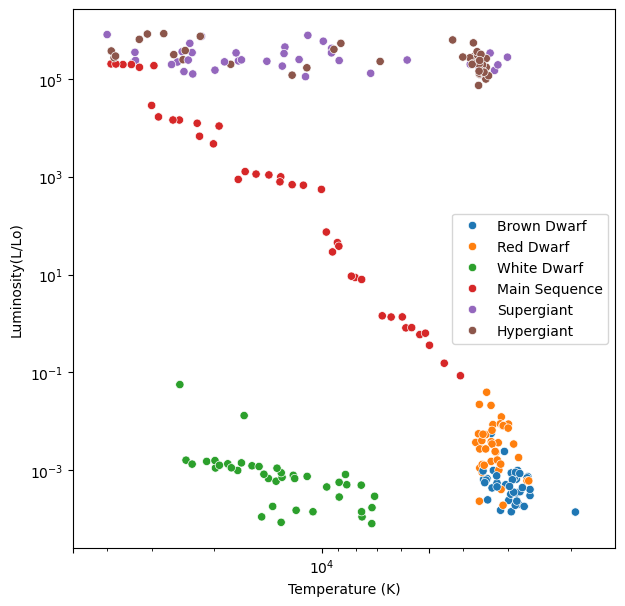

In [5]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [6]:
# Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers)
# first, we need to separate the data into two dataframes, one with the labels and one with the real numbers
# standardize the data so that one feature doesn't dominate the PCA algorithm

import numpy as np
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 


x_numeric = df_stars.select_dtypes(include=[np.number])

if 'Star type' in x_numeric.columns:
    x_numeric = x_numeric.drop(columns=['Star type'])



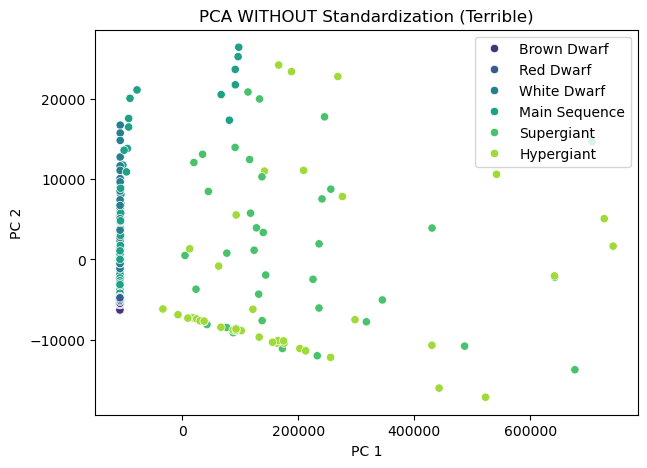

Explained variance ratio (Unscaled): [0.99760631 0.0023879 ]
(240, 2)


In [10]:
pca_bad = PCA(n_components=2, svd_solver='randomized')
x_pca_bad = pca_bad.fit_transform(x_numeric)
df_pca_bad = pd.DataFrame(x_pca_bad, columns=['PC 1', 'PC 2'])
plt.figure(figsize=(7, 5))


sns.scatterplot(data=df_pca_bad, x='PC 1', y='PC 2', hue=labels, palette='viridis')
plt.title("PCA WITHOUT Standardization (Terrible)")
plt.show()
print("Explained variance ratio (Unscaled):", pca_bad.explained_variance_ratio_)
print(x_pca_bad.shape)


In [14]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_numeric)

print(x_scaled.shape)


(240, 4)


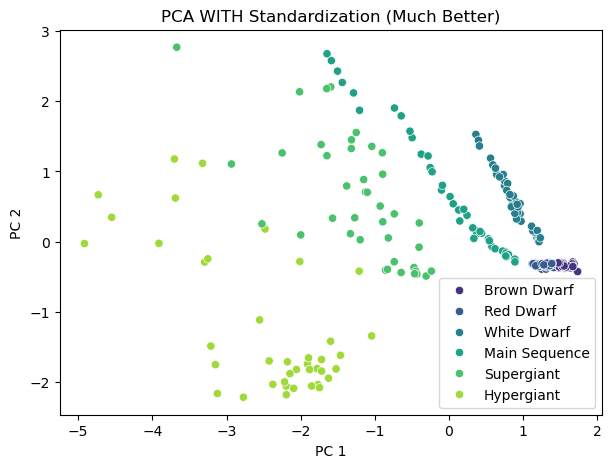

(240, 2)


In [18]:
pca_good = PCA(n_components=2, svd_solver='randomized')
x_pca_good = pca_good.fit_transform(x_scaled)
df_pca_good = pd.DataFrame(x_pca_good, columns=['PC 1', 'PC 2'])

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca_good, x='PC 1', y='PC 2', hue=labels, palette='viridis')
plt.title("PCA WITH Standardization (Much Better)")
plt.show()

print(x_pca_good.shape)

In [19]:
# How much variance is explained by those two components?
print("Explained variance ratio (Scaled):", pca_good.explained_variance_ratio_)
print(f"Total variance explained by 2 components:{sum(pca_good.explained_variance_ratio_) * 100:.2f}%")

Explained variance ratio (Scaled): [0.60357391 0.23500784]
Total variance explained by 2 components:83.86%
